# From probability map to coordinated drone routes

**Author:** Andrew Wheeler

**AI-use statement:** This notebook, its mathematical exposition, code, and figures were mostly generated using OpenAI Codex with GPT-5.6 Sol under the author's direction. Andrew Wheeler reviewed the work, requested substantive revisions, and takes responsibility for the final content.

## Abstract

**Objective.** We study the allocation of multiple search drones over a raster-valued posterior probability surface when each drone has a fixed scan budget and must follow a contiguous path. The objective is to maximize the probability mass searched without duplicate coverage.

**Methods.** The problem is formulated as a free-origin, free-destination grid variant of the Team Orienteering Problem. A time-indexed binary program provides exact solutions and feasibility certificates on small instances. For operational-scale rasters, we develop a path-based matheuristic comprising serpentine sweep generation, bidirectional beam construction, an exact CP-SAT set-packing master, and incumbent-centered translation enrichment. Optional local-topology constraints prevent isolated unsearched cells. A cell-order-statistic relaxation supplies a valid global upper bound. Negative search outcomes are incorporated through sequential Bayesian updating.

**Results.** On the 100 × 100 multimodal surface introduced by Wheeler, the refined four-drone, 100-cell plan searches 8.036% of prior probability and attains 99.48% of the unconstrained top-400-cell upper bound. Four 300-cell routes search 21.70% of prior probability. In a two-round four-drone example, a negative first search sets 400 cells to zero posterior probability; hole-free replanning raises cumulative detection probability from 8.04% after round 1 to 15.08% after round 2. The scalable method is also compared with a globally optimal solution on a small instance.

**Conclusions.** Explicit route ordering eliminates the disconnected-subtour defect of cell-selection formulations. The proposed decomposition produces valid, coordinated paths and quantifies solution quality without claiming global optimality when the full path space has not been enumerated.

**Keywords:** team orienteering; search theory; unmanned aerial vehicles; set packing; CP-SAT; Bayesian updating; route planning.

## Motivation and contribution

Andrew Wheeler's [2020 post](https://andrewpwheeler.com/2020/12/20/a-failed-attempt-at-optimal-search-paths/) asks a deceptively hard question: given a multimodal probability surface, how should a limited number of searchers traverse it without disconnected “hop-scotching”? This notebook turns that question into a precise optimization problem, validates the model against exact solutions, and solves Wheeler's original 100 × 100 simulated surface at operational scale.

The central contribution is a distinction between **selecting valuable cells** and **constructing executable routes**. The exact formulation makes traversal order explicit. The scalable method then separates legal single-drone path construction from multi-drone coordination, while retaining independent feasibility checks and honest upper bounds. Every plotted line below is an ordered, contiguous route—not merely a connected set of cells.

The motivation is wilderness search and rescue, but the same machinery applies to disaster assessment, wildlife surveys, maritime search, infrastructure inspection, environmental sensing, and other spatial searches with a probabilistic reward map.

## Algorithm at a glance

In plain language, the algorithm does two things: it first constructs many sensible routes for one drone, and then it chooses the combination of routes that works best for the whole fleet.

**Inputs.** The planner needs (i) a grid whose cell values sum to one, (ii) the number of available drones $k$, and (iii) the number of cells each drone can search, $L$. A legal route visits exactly $L$ different cells and moves only to an edge- or corner-adjacent cell. Different drones may start anywhere, but they cannot search the same cell in the same round.

The operational-scale algorithm follows these steps:

1. **Build plausible single-drone routes.** Place compact back-and-forth sweep patterns over promising parts of the map. Also grow paths outward from high-probability starting cells, retaining only the strongest partial paths at each step.
2. **Score every route.** A route's score is the sum of the probabilities of its cells. At this point routes are evaluated individually; they may still overlap one another.
3. **Coordinate the fleet.** Give the route library to CP-SAT. It selects exactly $k$ routes with the largest combined score subject to no shared cells.
4. **Improve how the routes fit together.** Shift the selected routes a few rows or columns in every direction, add those nearby alternatives to the library, and let CP-SAT select again. Repeating this step closes packing gaps that are invisible when routes are ranked one at a time.
5. **Validate the answer independently.** Check every path's length, cell indices, adjacency, lack of revisits, and lack of overlap with other drones. Recompute its probability directly from the raster.
6. **Replan after an unsuccessful search.** Reduce or zero the probability of cells that were searched, renormalize the posterior surface, and run the same route-generation and fleet-selection process again. Optional compactness constraints prevent isolated one-cell gaps.

The data flow is therefore

```text
probability map → candidate routes → CP-SAT fleet selection
        ↑                         ↓
Bayesian update ← validated plan ← local route refinement
```

The method is a **matheuristic**: route generation searches a carefully chosen subset of all possible paths, while CP-SAT finds the exact best combination inside that generated subset. Consequently, an `OPTIMAL` solver status certifies the best plan in the current route library, not necessarily the unknowable best plan among every possible grid path. Later sections define each step mathematically, validate it on a small exact instance, and report practical performance at larger scales.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from search_planner import (
    generate_candidates,
    greedy_endpoint_plan,
    isolated_uncovered_cells,
    make_probability_surface,
    path_score,
    plan_from_candidates,
    plot_paths,
    plot_surface,
    solve_exact_small,
    update_probability_after_no_detection,
    validate_paths,
)

OUTPUT = Path("artifacts")
OUTPUT.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 125, "savefig.dpi": 180, "font.size": 10})
pd.set_option("display.precision", 4)

## 1. The probability surface

Rossmo, Velarde, and Mahood motivate prioritizing search areas with probability maps that combine incomplete evidence through Bayesian updating. Their Joshua Tree case integrates earlier search tracks and a cell-phone-tower ping into a GIS probability surface. That work answers **where is the subject likely to be?**; the present problem answers **how should limited search assets move across that surface?**

Below I reproduce Wheeler's synthetic data exactly in substance: the same repeated point locations, Gaussian kernel bandwidth 2, extent 0–10, and normalization. The western mode is tall and concentrated; the northeastern mode is broader and carries substantial mass; a third mode sits in the southeast.

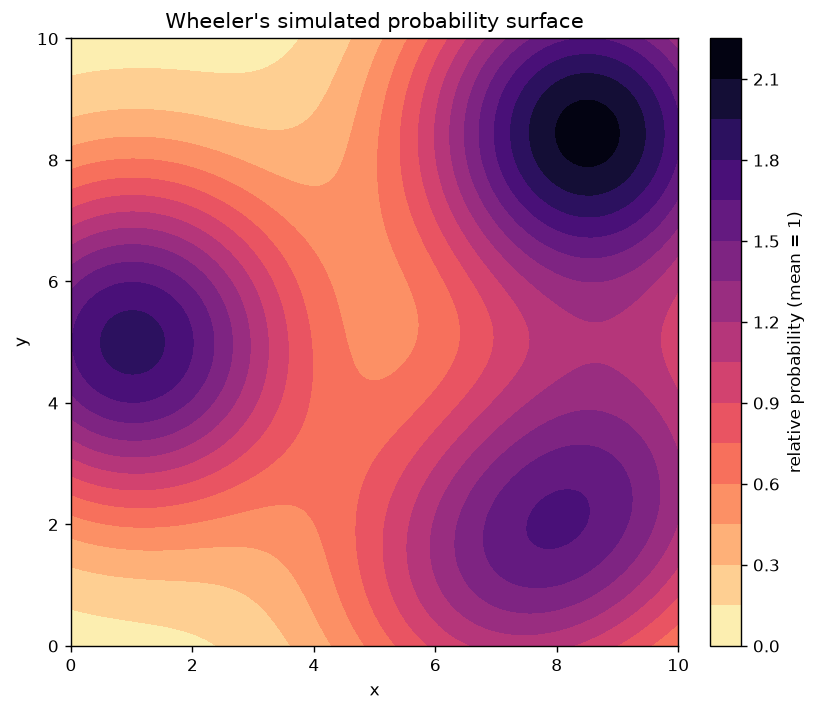

Grid: 100 × 100 = 10,000 cells
Probability sums to 1.000000000000


In [2]:
x, y, probability = make_probability_surface(grid_size=100)
assert np.isclose(probability.sum(), 1.0)

fig, ax = plt.subplots(figsize=(7.2, 5.8))
plot_surface(probability, ax=ax, title="Wheeler's simulated probability surface")
fig.tight_layout()
fig.savefig(OUTPUT / "probability_surface.png", bbox_inches="tight")
plt.show()

print(f"Grid: {probability.shape[0]} × {probability.shape[1]} = {probability.size:,} cells")
print(f"Probability sums to {probability.sum():.12f}")

## 2. Mathematical formulation

### 2.1 Search graph, routes, and decision criterion

Let $G=(V,A)$ be the directed search graph induced by a rectangular raster. A vertex $i\in V$ represents one searchable cell. Both orientations of arc $(i,j)$ belong to $A$ when $i$ and $j$ share an edge or corner; equivalently, their row and column indices have Chebyshev distance one. Let $n=|V|$, let $D=\{1,\ldots,k\}$ denote the drones, and let $T=\{1,\ldots,L\}$ denote the ordered scan positions available to each drone.

The probability vector $p=(p_1,\ldots,p_n)$ is a posterior distribution for one stationary target:

$$p_i\geq 0, \qquad \sum_{i\in V}p_i=1.$$

A route for drone $d$ is an injective map $r_d:T\rightarrow V$ such that $(r_d(t-1),r_d(t))\in A$ for every $t=2,\ldots,L$. Thus, a route is an ordered elementary path, not merely a connected subset of cells. The team plan is $R=(r_1,\ldots,r_k)$, subject to vertex disjointness across drones. Write

<style>
.jp-RenderedHTMLCommon table.symbol-definition-table {
  table-layout: auto !important;
  width: 52rem !important;
  max-width: 100% !important;
  margin-left: 0 !important;
  margin-right: auto !important;
}
.jp-RenderedHTMLCommon table.symbol-definition-table th,
.jp-RenderedHTMLCommon table.symbol-definition-table td {
  text-align: left !important;
}
.jp-RenderedHTMLCommon table.symbol-definition-table th:first-child,
.jp-RenderedHTMLCommon table.symbol-definition-table td:first-child {
  width: 12rem;
  white-space: nowrap;
}
</style>
<table class="symbol-definition-table">
<thead><tr><th>Symbol</th><th>Definition</th></tr></thead>
<tbody>
<tr><td>\(G=(V,A)\)</td><td>Directed queen-adjacency grid graph</td></tr>
<tr><td>\(n=\lvert V\rvert\)</td><td>Number of raster cells</td></tr>
<tr><td>\(D=\{1,\ldots,k\}\)</td><td>Drone index set</td></tr>
<tr><td>\(T=\{1,\ldots,L\}\)</td><td>Ordered scan positions per drone</td></tr>
<tr><td>\(p_i\)</td><td>Posterior probability that the target occupies cell \(i\)</td></tr>
<tr><td>\(r_d(t)\)</td><td>Cell visited by drone \(d\) at route position \(t\)</td></tr>
<tr><td>\(S(R)\)</td><td>Union of cells searched by team plan \(R\)</td></tr>
<tr><td>\(F(R;p)\)</td><td>Probability mass covered by plan \(R\) under surface \(p\)</td></tr>
</tbody>
</table>

$$S(R)=\bigcup_{d\in D}\{r_d(t):t\in T\}$$

for the searched cells. Under perfect detection, one stationary target, and no value from searching a cell twice within a round, the probability of detection is

$$F(R;p)=\Pr(\text{find}\mid R,p)=\sum_{i\in S(R)}p_i.$$

The optimization problem is therefore

$$R^*\in\arg\max_{R\in\mathcal F_{k,L}(G)}F(R;p),$$

where $\mathcal F_{k,L}(G)$ is the set of $k$ mutually vertex-disjoint elementary paths containing exactly $L$ vertices each. This is a free-origin, free-destination, unit-travel-time grid variant of the [Team Orienteering Problem](https://doi.org/10.1016/0377-2217(94)00289-4) (Chao, Golden, & Wasil, 1996).

### 2.2 Operational assumptions

The estimand $F(R;p)$ has a direct probability interpretation only under the following assumptions:

1. **One stationary target.** The target does not move during a planning round.
2. **Perfect cell-level detection.** If the target is in a scanned cell, it is found with probability one.
3. **Unit scan and travel cost.** Selecting $L$ cells represents $L-1$ adjacent moves plus the initial scanned cell.
4. **Free deployment and recovery.** Launch, recovery, and travel from a base to the first cell are outside the stated budget.
5. **Zero turn cost.** Direction changes do not alter resource consumption.
6. **No obstacles.** Every grid cell is flyable, and every queen-adjacent transition is feasible.
7. **No duplicate reward.** Within a round, a cell contributes probability mass at most once.

These assumptions isolate the routing question posed in the original example. They are not innocuous. A common depot adds origin and terminal constraints; wind and terrain replace unit arcs with directed costs; no-fly cells delete vertices or arcs; and a sensor footprint replaces vertex reward by the probability mass of the union of visible cells.

For a single scan with cell-specific probability of detection $q_i$, the expected reward becomes $p_iq_i$. If a plan permits $n_i$ independent scans of cell $i$, its contribution is nonlinear:

$$p_i\left[1-(1-q_i)^{n_i}\right].$$

The present within-round model forbids repeat credit, while the sequential analysis later in the notebook updates the posterior between rounds.

## 3. Optimization methodology

### 3.1 Exact time-indexed formulation

Define a binary decision variable

$$x_{dti}=\begin{cases}
1,&\text{if drone }d\text{ scans cell }i\text{ at position }t,\\
0,&\text{otherwise.}
\end{cases}$$

Let $N(i)=\{j:(j,i)\in A\}$ be the predecessor neighbors of cell $i$. The complete time-indexed integer program is

$$\max_x \quad \sum_{d\in D}\sum_{t\in T}\sum_{i\in V}p_i x_{dti} \tag{1}$$

subject to

$$\sum_{i\in V}x_{dti}=1
\qquad \forall d\in D,\ t\in T, \tag{2}$$

$$x_{dti}\leq\sum_{j\in N(i)}x_{d,t-1,j}
\qquad \forall d\in D,\ i\in V,\ t=2,\ldots,L, \tag{3}$$

$$\sum_{d\in D}\sum_{t\in T}x_{dti}\leq1
\qquad \forall i\in V, \tag{4}$$

$$x_{dti}\in\{0,1\}. \tag{5}$$

Constraint (2) assigns exactly one cell to every drone-position pair. Constraint (3) forces each assigned cell to follow an adjacent assigned cell. Constraint (4) simultaneously prevents self-intersection and inter-drone overlap. Free starts and ends require no depot constraints. Interchangeable-drone symmetry is reduced computationally by ordering start-cell indices,

$$\sum_{i\in V} i\,x_{d,1,i}<\sum_{i\in V} i\,x_{d+1,1,i},
\qquad d=1,\ldots,k-1. \tag{6}$$

**Proposition 1 (route feasibility).** Constraints (2)–(5) are equivalent to selecting $k$ mutually vertex-disjoint elementary paths of length $L$ in $G$.

*Proof.* For each $(d,t)$, (2) selects one vertex. For $t>1$, (3) guarantees an arc from the unique vertex selected at $t-1$ to the vertex selected at $t$. Constraint (4) prevents any selected vertex from appearing at two positions or on two drones, so each resulting walk is elementary and routes are mutually disjoint. Conversely, the incidence vector of any $k$ such paths satisfies (2)–(5). $\square$

This formulation is exact, but it contains $kLn$ binary variables and approximately $kLn+n$ structural constraints. The largest experiment here ($n=10{,}000$, $k=8$, $L=300$) would create 24 million binary variables before presolve. Since even the single-route orienteering problem is NP-hard, this growth is structural rather than a solver-specific defect. Time-indexed and path-based exact formulations are standard in the TOP literature; see [Poggi, Viana, and Uchoa (2010)](https://doi.org/10.4230/OASIcs.ATMOS.2010.142).

### 3.2 Exact path-based master problem

Let $\Omega_L$ be the set of every elementary $L$-vertex path in $G$. For route $r\in\Omega_L$, define its cell-incidence coefficient and reward as

$$a_{ir}=\mathbf 1(i\in r), \qquad c_r=\sum_{i\in V}p_i a_{ir}.$$

With $z_r=1$ when route $r$ is assigned to a drone, an alternative exact formulation is

$$\max_z \quad \sum_{r\in\Omega_L}c_rz_r \tag{7}$$

subject to

$$\sum_{r\in\Omega_L}z_r=k, \tag{8}$$

$$\sum_{r\in\Omega_L}a_{ir}z_r\leq1
\qquad \forall i\in V, \tag{9}$$

$$z_r\in\{0,1\}. \tag{10}$$

This is a weighted cardinality-constrained set-packing model. If all of $\Omega_L$ were available, (7)–(10) would be exact. However, $|\Omega_L|$ grows exponentially. Exact branch-cut-and-price methods address this with dual-guided route pricing. The implementation here instead constructs a finite library $\widehat\Omega_L\subset\Omega_L$ heuristically, then solves (7)–(10) exactly over that restricted library using Google OR-Tools CP-SAT. It is therefore a **matheuristic with an exact restricted master**, not full column generation.

### 3.3 Route generation

Two complementary mechanisms populate $\widehat\Omega_L$.

**Compact sweep templates.** For each selected width $w$, a serpentine path is constructed in a $w\times\lceil L/w\rceil$ rectangle and truncated after exactly $L$ cells. All unique rotations and reflections are considered. For a relative template $Q=\{(\Delta r_t,\Delta c_t)\}_{t=1}^L$, every feasible translation has score

$$c(Q;r,c)=\sum_{t=1}^L p_{r+\Delta r_t,\ c+\Delta c_t}.$$

These scores are evaluated vectorially. The highest-scoring global anchors and the strongest anchor in each spatial stratum are retained, preserving both intensification near modes and geographic diversity.

**Bidirectional beam construction.** Beam states contain an ordered partial path $P$, its visited set, its two endpoints, and accumulated reward $g(P)=\sum_{i\in P}p_i$. A state can be extended by an unused neighbor of either endpoint. Candidate extensions are ranked by

$$h(P\oplus v)=g(P\oplus v)
+0.65\max_{u\in N(v)\setminus(P\cup\{v\})}p_u
+0.03\,\bar p\,|N(v)\setminus(P\cup\{v\})|, \tag{11}$$

where $\bar p=1/n$. The second term is a one-step probability look-ahead; the third weakly discourages trapping an endpoint. The implementation retains 18 states per beam step and begins from probability-separated seeds plus a coarse geographic grid. Only complete, validated $L$-cell paths enter the library.

### 3.4 Restricted-master refinement

Initial pruning ranks routes individually, whereas the master values how routes pack jointly. This distinction caused the visible gap in the first 4-by-100 result. To correct it efficiently, after each restricted-master solution the algorithm translates each incumbent route by

$$(\delta_r,\delta_c)\in\{-\rho,\ldots,\rho\}^2\setminus\{(0,0)\},$$

with $\rho=3$, discards out-of-grid translations, adds previously unseen routes, and re-solves. Three enrichment rounds are used. Translation preserves path simplicity and adjacency by construction; the master continues to enforce inter-route disjointness. This neighborhood enrichment recovered the cells between the original orange and green routes without enumerating all translations of all templates.

The full procedure is:

1. Generate sweep and beam routes to form $\widehat\Omega_L$.
2. Solve the restricted set-packing master (7)–(10).
3. Translate incumbent routes within radius $\rho$ and add new feasible columns.
4. Repeat steps 2–3 for three rounds.
5. Validate route length, bounds, within-route uniqueness, between-route disjointness, and every consecutive move.

This design follows the broader TOP literature's use of local-search diversification and exact route-selection ideas, while exploiting the regular raster and zero-turn-cost assumptions of this application. See, for example, [Vansteenwegen et al. (2009)](https://doi.org/10.1016/j.ejor.2008.02.037) and the [orienteering survey](https://doi.org/10.1016/j.ejor.2010.03.045).

### 3.5 Bounds and interpretation of solver status

Let $p_{(1)}\geq\cdots\geq p_{(n)}$ be the cell probabilities in descending order and let $m=kL$. Any feasible plan covers exactly $m$ distinct cells, so

$$U_m=\sum_{j=1}^{m}p_{(j)} \tag{12}$$

is a valid global upper bound obtained by dropping all path and adjacency constraints.

**Proposition 2 (global quality certificate).** If a feasible plan has value $C$ and the unknown global optimum is $C^*$, then

$$C\leq C^*\leq U_m
\qquad\text{and}\qquad
\frac{C}{C^*}\geq\frac{C}{U_m}. \tag{13}$$

Thus $1-C/U_m$ is a conservative maximum relative shortfall, even though $U_m$ may itself be unattainable. Separately, CP-SAT's best bound for (7)–(10) measures the gap **within** $\widehat\Omega_L$. A zero restricted-master gap proves that no better combination exists among generated routes; it does not prove $C=C^*$ unless the full route set has been enumerated. The notebook reports these two quantities separately and reserves the label “exact optimum” for the independently solved small time-indexed instance.

### 3.6 Computational implementation

The restricted masters are solved with [Google OR-Tools CP-SAT](https://developers.google.com/optimization/cp/cp_solver) (Perron & Furnon, 2019). The implementation supplies integer objective coefficients, so route probabilities are multiplied by $10^{12}$ and rounded to the nearest integer. This scale preserves distinctions far below any reported result while remaining safely inside signed 64-bit arithmetic. Each restricted master receives a 12-second limit in the full experiments, uses eight search workers, and records the returned feasibility status and best bound. Small exact instances receive a longer limit. Route generation is deterministic; CP-SAT random seeds are fixed, although parallel search order can vary by platform. Every reported full-scale restricted master terminated with an optimal status for its final enriched library.

The implementation treats validation as part of the algorithm rather than presentation. For every returned plan it independently checks: (i) exactly $L$ cells per drone; (ii) valid cell indices; (iii) no within-route repeat; (iv) Chebyshev distance one for every move; and (v) no cell shared between drones. Objective values are then recomputed directly from the probability raster rather than trusted from solver-scaled coefficients.

## 4. Exact validation on a small instance

The next experiment solves a 6 × 6, two-drone, five-cell instance twice: once with the full time-indexed model and once with the scalable method. It also includes a sequential endpoint-greedy baseline in the spirit of the original post. The exact solver's status and bound provide a genuine certificate.

In [3]:
_, _, small_probability = make_probability_surface(grid_size=6)
small_k, small_length = 2, 5

exact = solve_exact_small(small_probability, small_k, small_length, time_limit=60)
small_candidates = generate_candidates(small_probability, small_length)
hybrid = plan_from_candidates(
    small_probability, small_candidates, small_k, small_length, time_limit=15
)
greedy_paths = greedy_endpoint_plan(small_probability, small_k, small_length)
greedy_score = path_score(small_probability, greedy_paths)

for name, paths in [("exact", exact.paths), ("hybrid", hybrid.paths), ("greedy", greedy_paths)]:
    validate_paths(paths, small_probability.shape, small_length)

validation = pd.DataFrame(
    [
        {"method": "Exact time-indexed CP-SAT", "covered_probability": exact.score,
         "percent_of_exact": 100.0, "status": exact.status},
        {"method": "Hybrid route library + CP-SAT", "covered_probability": hybrid.score,
         "percent_of_exact": 100 * hybrid.score / exact.score, "status": hybrid.status},
        {"method": "Sequential endpoint greedy", "covered_probability": greedy_score,
         "percent_of_exact": 100 * greedy_score / exact.score, "status": "feasible"},
    ]
)
display(validation.style.format({"covered_probability": "{:.4%}", "percent_of_exact": "{:.2f}%"}))
assert exact.status == "OPTIMAL"
assert exact.candidate_gap < 1e-8
print(f"Exact certificate: objective = bound = {exact.score:.8f}")

,method,covered_probability,percent_of_exact,status
0,Exact time-indexed CP-SAT,44.3914%,100.00%,OPTIMAL
1,Hybrid route library + CP-SAT,44.3914%,100.00%,OPTIMAL (enriched candidate library)
2,Sequential endpoint greedy,43.2220%,97.37%,feasible


Exact certificate: objective = bound = 0.44391379


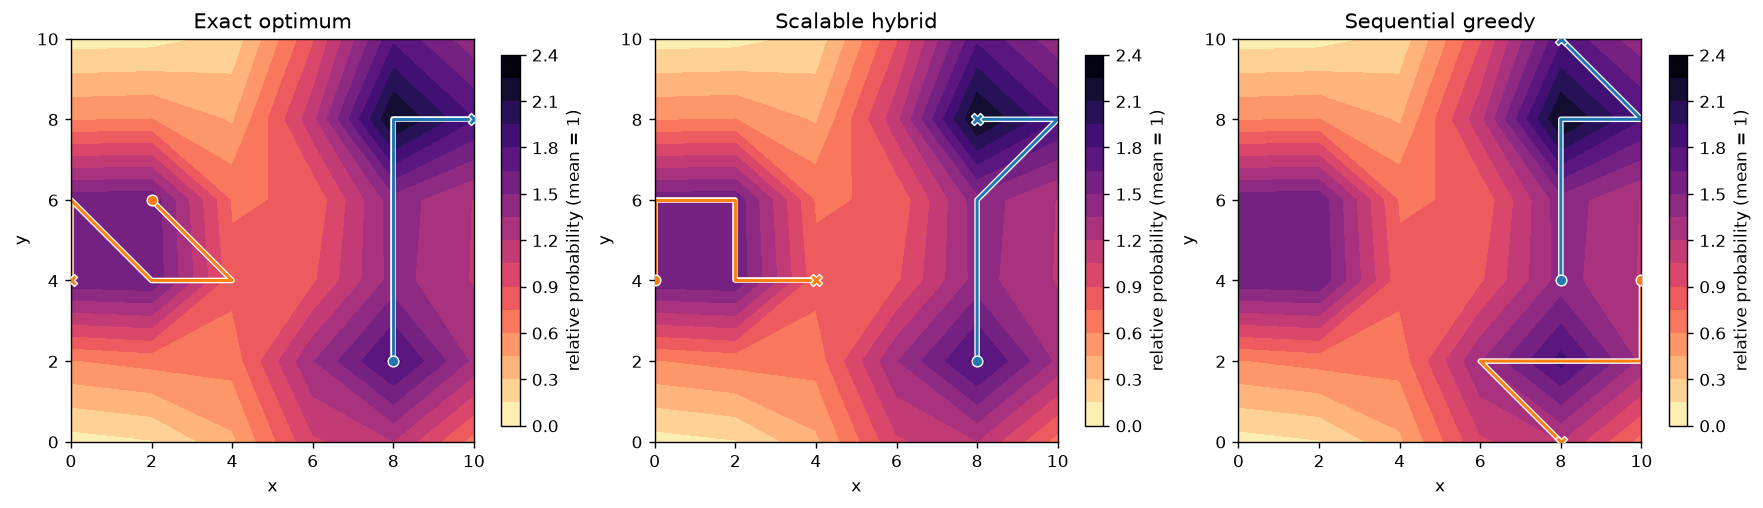

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
plot_paths(small_probability, exact.paths, axes[0], "Exact optimum")
plot_paths(small_probability, hybrid.paths, axes[1], "Scalable hybrid")
plot_paths(small_probability, greedy_paths, axes[2], "Sequential greedy")
for ax in axes:
    legend = ax.get_legend()
    if legend:
        legend.remove()
fig.savefig(OUTPUT / "small_exact_validation.png", bbox_inches="tight")
plt.show()

The visual audit matters: each route is shown in traversal order, with a circle at its start and an X at its end. Lines may touch or cross geometrically at diagonal moves, but the validation function confirms that no cell is repeated within or across drones.

## 5. Full-scale plans for different fleet sizes and budgets

We now return to all 10,000 cells. Candidate routes only depend on path length, so the same library can be reused across fleet sizes. This is operationally convenient: once routes are generated, incident command can rapidly evaluate how the allocation changes as drones become available.

In [5]:
lengths = [100, 300]
fleet_sizes = [1, 2, 4, 8]

candidate_libraries = {}
for length in lengths:
    candidate_libraries[length] = generate_candidates(probability, length)
    print(f"length {length}: {len(candidate_libraries[length]):,} valid candidate routes")

plans = {}
rows = []
for length in lengths:
    for drones in fleet_sizes:
        result = plan_from_candidates(
            probability,
            candidate_libraries[length],
            drones=drones,
            length=length,
            time_limit=12,
            random_seed=2026 + drones + length,
        )
        validate_paths(result.paths, probability.shape, length)
        plans[(drones, length)] = result
        rows.append(
            {
                "drones": drones,
                "cells_per_drone": length,
                "total_unique_cells": drones * length,
                "covered_probability": result.score,
                "global_relaxation_bound": result.global_relaxation_bound,
                "fraction_of_global_bound": result.score / result.global_relaxation_bound,
                "candidate_gap": result.candidate_gap,
                "runtime_seconds": result.runtime_seconds,
                "status": result.status,
            }
        )

results = pd.DataFrame(rows)
display(
    results.style.format(
        {
            "covered_probability": "{:.2%}",
            "global_relaxation_bound": "{:.2%}",
            "fraction_of_global_bound": "{:.2%}",
            "candidate_gap": "{:.3%}",
            "runtime_seconds": "{:.2f}",
        }
    )
)
results.to_csv(OUTPUT / "scenario_results.csv", index=False)

length 100: 4,771 valid candidate routes


length 300: 4,114 valid candidate routes


,drones,cells_per_drone,total_unique_cells,covered_probability,global_relaxation_bound,fraction_of_global_bound,candidate_gap,runtime_seconds,status
0,1,100,100,2.13%,2.13%,99.92%,0.000%,0.06,OPTIMAL (enriched candidate library)
1,2,100,200,4.18%,4.18%,99.86%,0.000%,27.82,OPTIMAL (enriched candidate library)
2,4,100,400,8.04%,8.08%,99.48%,0.000%,29.44,OPTIMAL (enriched candidate library)
3,8,100,800,15.10%,15.29%,98.77%,0.000%,28.47,OPTIMAL (enriched candidate library)
4,1,300,300,6.15%,6.17%,99.78%,0.000%,0.15,OPTIMAL (enriched candidate library)
5,2,300,600,11.41%,11.75%,97.07%,0.000%,18.43,OPTIMAL (enriched candidate library)
6,4,300,1200,21.70%,22.01%,98.58%,0.000%,39.90,OPTIMAL (enriched candidate library)
7,8,300,2400,39.19%,40.32%,97.20%,0.000%,44.00,OPTIMAL (enriched candidate library)


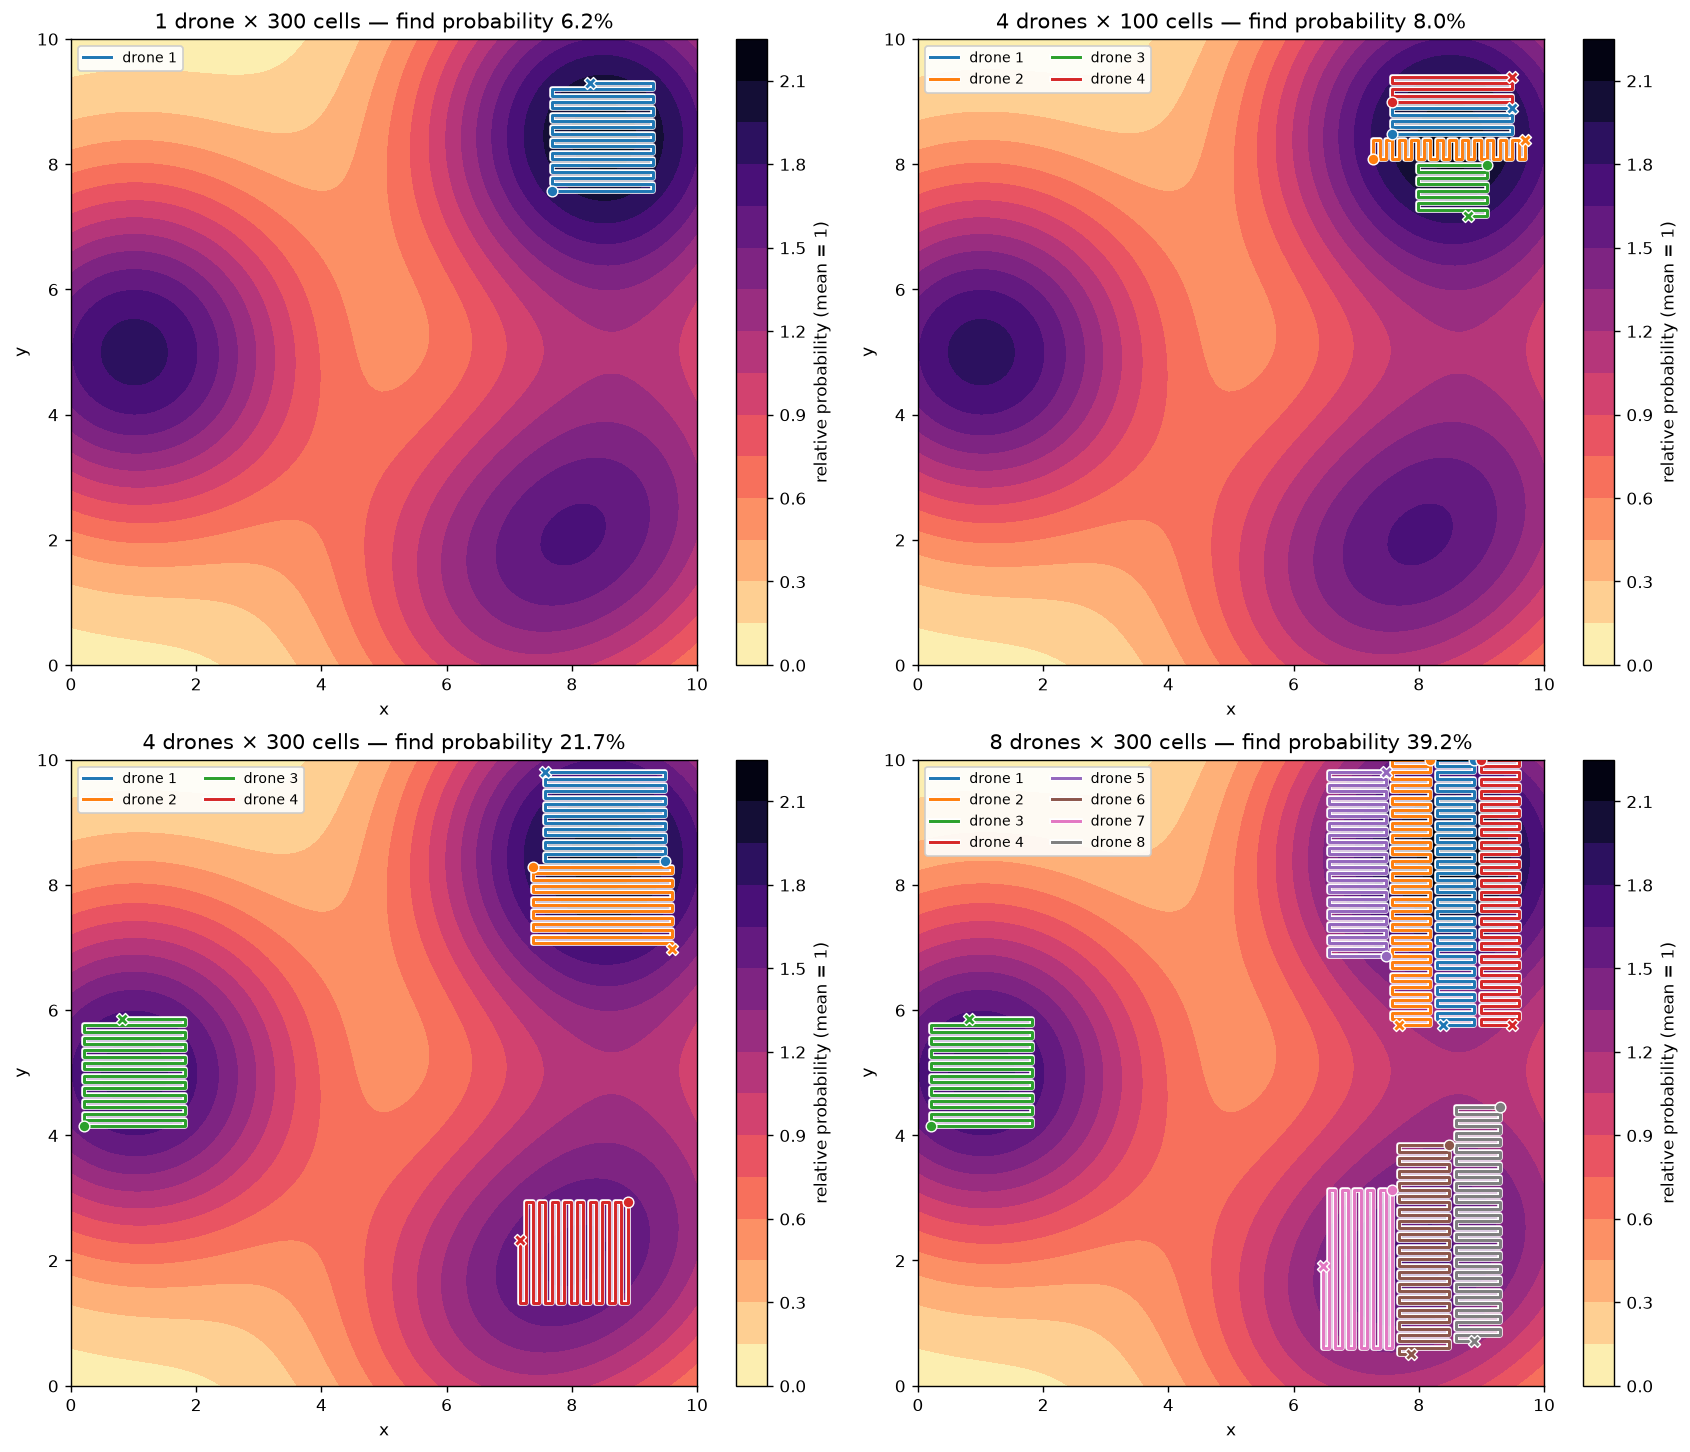

In [6]:
show_cases = [(1, 300), (4, 100), (4, 300), (8, 300)]
fig, axes = plt.subplots(2, 2, figsize=(13.5, 11.5), constrained_layout=True)
for ax, (drones, length) in zip(axes.ravel(), show_cases):
    result = plans[(drones, length)]
    plot_paths(
        probability,
        result.paths,
        ax=ax,
        title=(f"{drones} drone{'s' if drones > 1 else ''} × {length} cells "
               f"— find probability {result.score:.1%}"),
    )
fig.savefig(OUTPUT / "full_scale_flight_paths.png", bbox_inches="tight")
plt.show()

## 6. A second search round after no detection

Suppose four drones complete the 100-cell routes from round 1 but do not find the target. Let $p_i^{(r)}$ denote the probability at the start of round $r$, $s_i^{(r)}$ the number of successful scans assigned to cell $i$ during that round, and $q_i$ the probability of detecting the target in one scan conditional on its presence. Under conditionally independent detection attempts, the likelihood of no detection in cell $i$ is

$$\ell_i^{(r)}=(1-q_i)^{s_i^{(r)}}.$$

Bayes' rule gives the posterior after the negative search:

$$p_i^{(r+1)}=
\frac{p_i^{(r)}\ell_i^{(r)}}
{\sum_{j\in V}p_j^{(r)}\ell_j^{(r)}}. \tag{14}$$

The denominator is the marginal probability of observing no detection during round $r$. With perfect detection, $q_i=1$, a successfully searched cell has $\ell_i^{(r)}=0$ and therefore receives literal zero posterior probability. With imperfect detection, searched cells retain diminished mass and can rationally be searched again.

Let $C_r$ be the optimized conditional detection probability in round $r$. The unconditional contribution of round $r$ is

$$\Delta_r=C_r\prod_{h=1}^{r-1}(1-C_h), \tag{15}$$

and cumulative detection probability through $R$ rounds is

$$C_{1:R}=\sum_{r=1}^{R}\Delta_r
=1-\prod_{r=1}^{R}(1-C_r). \tag{16}$$

Equations (14)–(16) assume a stationary target. If movement between rounds is represented by a Markov transition matrix $M$, the negative-search posterior is propagated before replanning: $p^{(r+1)}=M^\top\widetilde p^{(r)}$.

This update assumes the drones **completed** their searches and failed to detect the target. If a drone itself failed before scanning its assigned cells, those unsearched cells have $s_i^{(r)}=0$ and retain their prior likelihood weight. Zero-probability cells remain traversable in the routing graph; converting them to obstacles would be a different operational assumption.

### 6.1 Avoiding isolated unsearched cells

Pure probability maximization can select a route that surrounds a low-valued cell without scanning it. Such a one-cell pocket is visually awkward and may be operationally undesirable even though the route is mathematically valid. Let

$$z_i=\sum_{\omega\ni i}x_\omega$$

indicate whether cell $i$ is searched by any selected route, and let $N_4(i)$ contain its north, south, east, and west neighbors. For every nonboundary cell, the optional no-isolated-hole policy adds

$$\sum_{j\in N_4(i)}z_j-4z_i\leq 3. \tag{17}$$

If $z_i=0$, (17) requires at least one orthogonal neighbor to remain unsearched, so cell $i$ cannot be a one-cell enclosed pocket. If $z_i=1$, the constraint is inactive. Candidate generation first removes routes that create such a hole individually; coverage variables in the restricted master also prevent a hole created jointly by multiple routes. This is a precise local compactness rule, not a ban on every larger enclosed region. General component-level exclusions would require connectivity cuts or iterative flood-fill separation.

In [7]:
round1 = plans[(4, 100)]
round2_probability = update_probability_after_no_detection(
    probability, round1.paths, detection_probability=1.0
)
round1_cells = set(node for path in round1.paths for node in path)
round1_holes = isolated_uncovered_cells(round1.paths, probability.shape)

assert np.isclose(round2_probability.sum(), 1.0)
assert np.all(round2_probability.ravel()[list(round1_cells)] == 0.0)

round2_candidates_unconstrained = generate_candidates(round2_probability, length=100)
round2_unconstrained = plan_from_candidates(
    round2_probability,
    round2_candidates_unconstrained,
    drones=4,
    length=100,
    time_limit=12,
    random_seed=3026,
)
unconstrained_holes = isolated_uncovered_cells(
    round2_unconstrained.paths, round2_probability.shape
)

round2_candidates = generate_candidates(
    round2_probability, length=100, forbid_isolated_holes=True
)
round2 = plan_from_candidates(
    round2_probability,
    round2_candidates,
    drones=4,
    length=100,
    time_limit=12,
    random_seed=3026,
    forbid_isolated_holes=True,
)
validate_paths(round2.paths, round2_probability.shape, expected_length=100)
round2_holes = isolated_uncovered_cells(round2.paths, round2_probability.shape)
assert not round2_holes
round2_cells = set(node for path in round2.paths for node in path)
repeat_steps = len(round1_cells & round2_cells)

round1_find = round1.score
round2_find_given_failure = round2.score
round2_unconditional_increment = (1.0 - round1_find) * round2_find_given_failure
cumulative_find = round1_find + round2_unconditional_increment

sequential_results = pd.DataFrame(
    [
        {
            "round": 1,
            "zero_probability_cells_before_round": 0,
            "conditional_find_probability": round1_find,
            "unconditional_probability_increment": round1_find,
            "cumulative_find_probability": round1_find,
            "isolated_uncovered_cells": len(round1_holes),
        },
        {
            "round": 2,
            "zero_probability_cells_before_round": len(round1_cells),
            "conditional_find_probability": round2_find_given_failure,
            "unconditional_probability_increment": round2_unconditional_increment,
            "cumulative_find_probability": cumulative_find,
            "isolated_uncovered_cells": len(round2_holes),
        },
    ]
)
display(
    sequential_results.style.format(
        {
            "conditional_find_probability": "{:.2%}",
            "unconditional_probability_increment": "{:.2%}",
            "cumulative_find_probability": "{:.2%}",
        }
    )
)
print(f"Round-1 cells assigned zero posterior probability: {len(round1_cells)}")
print(f"Round-2 steps through zero-probability round-1 cells: {repeat_steps}")
round2_policy_comparison = pd.DataFrame(
    [
        {
            "policy": "probability only",
            "conditional_find_probability": round2_unconstrained.score,
            "isolated_uncovered_cells": len(unconstrained_holes),
            "status": round2_unconstrained.status,
        },
        {
            "policy": "forbid isolated holes",
            "conditional_find_probability": round2.score,
            "isolated_uncovered_cells": len(round2_holes),
            "status": round2.status,
        },
    ]
)
display(round2_policy_comparison.style.format({"conditional_find_probability": "{:.2%}"}))
round2_policy_comparison.to_csv(OUTPUT / "round2_hole_policy.csv", index=False)
sequential_results.to_csv(OUTPUT / "sequential_round_results.csv", index=False)

,round,zero_probability_cells_before_round,conditional_find_probability,unconditional_probability_increment,cumulative_find_probability,isolated_uncovered_cells
0,1,0,8.04%,8.04%,8.04%,0
1,2,400,7.66%,7.04%,15.08%,0


Round-1 cells assigned zero posterior probability: 400
Round-2 steps through zero-probability round-1 cells: 0


,policy,conditional_find_probability,isolated_uncovered_cells,status
0,probability only,7.81%,4,OPTIMAL (enriched candidate library)
1,forbid isolated holes,7.66%,0,OPTIMAL (enriched candidate library)


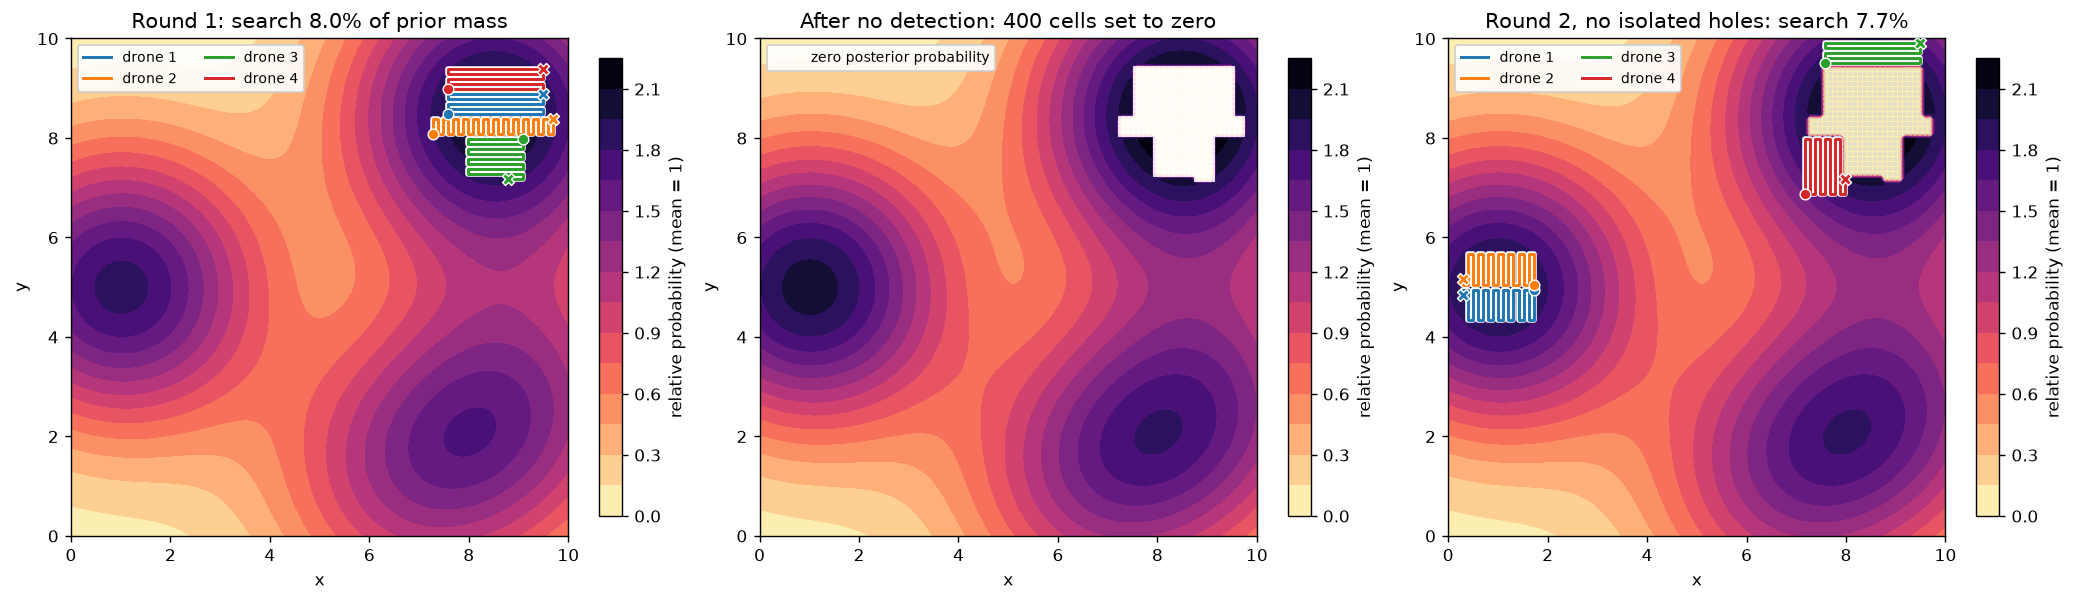

In [8]:
round1_coords = np.array([divmod(node, probability.shape[1]) for node in sorted(round1_cells)])
old_x = round1_coords[:, 1] * 10 / (probability.shape[1] - 1)
old_y = round1_coords[:, 0] * 10 / (probability.shape[0] - 1)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2), constrained_layout=True)
plot_paths(
    probability,
    round1.paths,
    axes[0],
    f"Round 1: search {round1_find:.1%} of prior mass",
)
plot_surface(
    round2_probability,
    axes[1],
    "After no detection: 400 cells set to zero",
)
axes[1].scatter(old_x, old_y, s=9, marker="s", color="white", alpha=0.85,
                linewidth=0, label="zero posterior probability")
axes[1].legend(loc="upper left", fontsize=8, framealpha=0.9)
plot_paths(
    round2_probability,
    round2.paths,
    axes[2],
    f"Round 2, no isolated holes: search {round2_find_given_failure:.1%}",
)
axes[2].scatter(old_x, old_y, s=7, marker="s", color="lightgray", alpha=0.55,
                linewidth=0, zorder=1.5)
fig.savefig(OUTPUT / "two_round_search.png", bbox_inches="tight")
plt.show()

The unconstrained second-round plan enclosed four individual cells. Enforcing (17) removes all four at a cost of approximately 0.15 percentage points of conditional detection probability (7.81% to 7.66%). The plotted plan is the constrained solution. Zero-valued cells remain legal transit cells but contribute nothing to the objective. Conditional and cumulative probabilities are kept separate: round 2's objective is conditional on the round-1 failure, while its unconditional contribution is multiplied by the probability of reaching round 2.

## 7. Computational timing and scaling

### 7.1 Benchmark design

Wall-clock timing was measured separately for (i) probability-surface construction, (ii) candidate-route generation, and (iii) restricted-master solution plus translation refinement. Their sum is reported as **cold total time**. When several fleet sizes use the same grid and 100-cell route length, candidate generation is performed once and reused; the cold total nevertheless includes that measured generation cost to represent a fresh planning request. **Warm replanning time** is the planning column alone.

The benchmark crosses grid sides $g\in\{10,50,100,200,500,1000\}$ with $k\in\{1,4,8\}$ drones. Routes contain 100 cells per drone whenever feasible. On the 10-by-10 grid, $L=\lfloor100/k\rfloor$ so mutually disjoint routes fit. To bound experiment duration, each restricted-master call receives five seconds and two translation-refinement rounds are used, for at most three master calls per scenario plus model-building time. These settings are deliberately shorter than the principal 100-by-100 analysis; solver status must therefore be read alongside time.

Each case was run once with `time.perf_counter`; these are engineering measurements, not distributional estimates from repeated trials. The computer was otherwise available for normal interactive use. CP-SAT used CPU threads only—no GPU acceleration. The benchmark is fully reproducible with `uv run python benchmark_scaling.py`.

In [9]:
import json

with open(OUTPUT / "benchmark_machine.json", encoding="utf-8") as handle:
    machine = json.load(handle)
timings = pd.read_csv(OUTPUT / "scaling_benchmark.csv")

machine_fields = [
    ("CPU", machine["cpu"]),
    ("Physical / logical cores", f'{machine["physical_cores"]} / {machine["logical_cores"]}'),
    ("Installed memory", f'{machine["installed_memory_gib"]:.2f} GiB'),
    ("Operating system", machine["operating_system"]),
    ("Python", machine["python_version"]),
    ("NumPy", machine["numpy_version"]),
    ("Solver", f'{machine["solver"]} {machine["ortools_version"]}'),
    ("CP-SAT workers", machine["solver_workers"]),
    ("GPU used", machine["gpu_used"]),
]
machine_table = pd.DataFrame(machine_fields, columns=["component", "specification"])
display(machine_table.style.hide(axis="index"))

timing_table = timings[
    [
        "grid_side", "grid_cells", "drones", "cells_per_drone",
        "surface_seconds", "candidate_generation_seconds",
        "planning_seconds", "cold_total_seconds",
        "initial_candidate_count", "fraction_of_global_bound", "status",
    ]
].copy()
timing_table["grid"] = timing_table["grid_side"].astype(str) + "²"
timing_table = timing_table.drop(columns="grid_side")
timing_table = timing_table[
    ["grid", "grid_cells", "drones", "cells_per_drone", "surface_seconds",
     "candidate_generation_seconds", "planning_seconds", "cold_total_seconds",
     "initial_candidate_count", "fraction_of_global_bound", "status"]
]
display(
    timing_table.style.format(
        {
            "grid_cells": "{:,}",
            "surface_seconds": "{:.3f}",
            "candidate_generation_seconds": "{:.3f}",
            "planning_seconds": "{:.3f}",
            "cold_total_seconds": "{:.3f}",
            "initial_candidate_count": "{:,}",
            "fraction_of_global_bound": "{:.2%}",
        }
    ).hide(axis="index")
)

component,specification
CPU,Intel(R) Core(TM) i3-9100F CPU @ 3.60GHz
Physical / logical cores,4 / 4
Installed memory,31.93 GiB
Operating system,Windows-10-10.0.19045-SP0
Python,3.12.12
NumPy,2.5.2
Solver,Google OR-Tools CP-SAT 9.15.6755
CP-SAT workers,8
GPU used,False


grid,grid_cells,drones,cells_per_drone,surface_seconds,candidate_generation_seconds,planning_seconds,cold_total_seconds,initial_candidate_count,fraction_of_global_bound,status
10²,100,1,100,0.001,1.154,0.001,1.155,4,100.00%,OPTIMAL (enriched candidate library)
10²,100,4,25,0.001,0.512,1.623,2.136,"1,235",100.00%,OPTIMAL (enriched candidate library)
10²,100,8,12,0.001,0.225,15.376,15.601,"1,337",100.00%,FEASIBLE (enriched candidate library)
50²,"2,500",1,100,0.001,4.052,0.055,4.108,"4,676",99.93%,OPTIMAL (enriched candidate library)
50²,"2,500",4,100,0.001,4.052,12.455,16.507,"4,676",92.75%,FEASIBLE (enriched candidate library)
50²,"2,500",8,100,0.001,4.052,18.989,23.042,"4,676",92.00%,FEASIBLE (enriched candidate library)
100²,"10,000",1,100,0.001,3.952,0.058,4.011,"4,771",99.92%,OPTIMAL (enriched candidate library)
100²,"10,000",4,100,0.001,3.952,18.204,22.157,"4,771",98.02%,FEASIBLE (enriched candidate library)
100²,"10,000",8,100,0.001,3.952,18.427,22.380,"4,771",94.25%,FEASIBLE (enriched candidate library)
200²,"40,000",1,100,0.005,4.614,0.060,4.678,"4,797",99.97%,OPTIMAL (enriched candidate library)


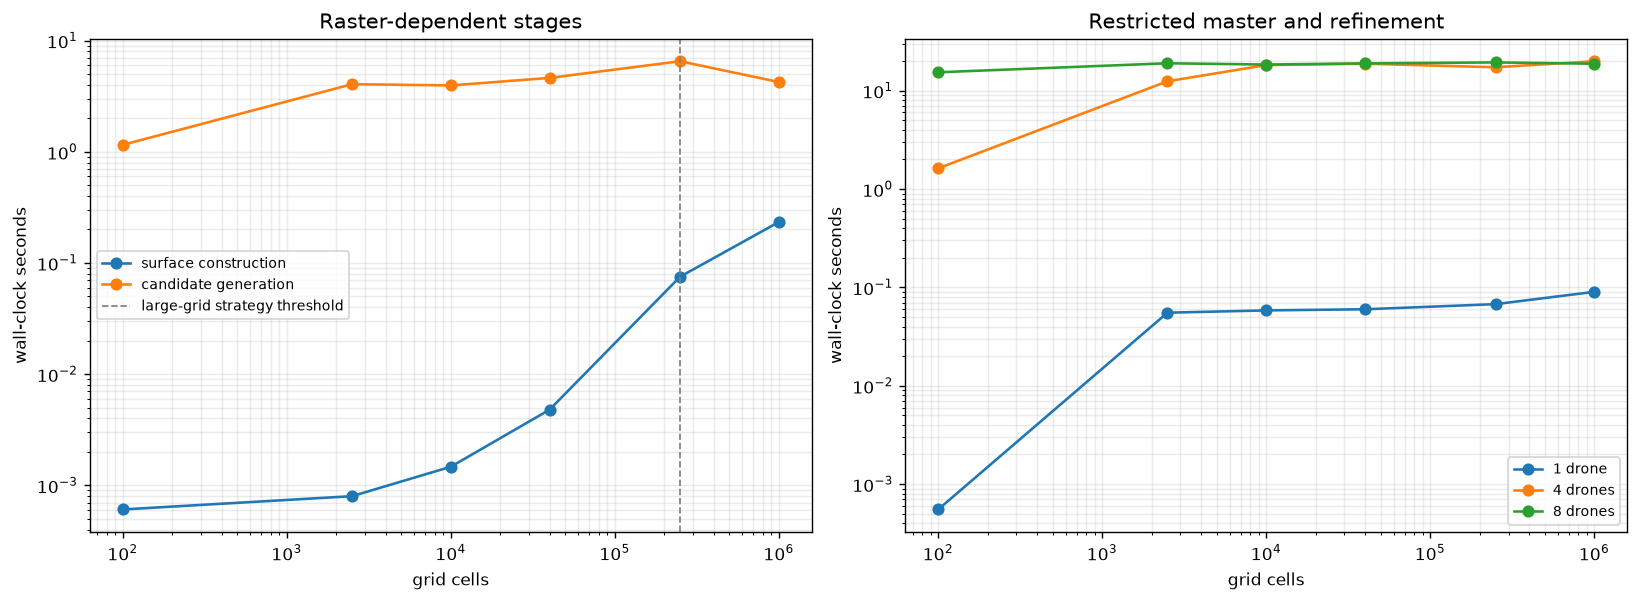

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7), constrained_layout=True)

by_grid = timings.sort_values("grid_cells").drop_duplicates("grid_cells")
axes[0].plot(by_grid["grid_cells"], by_grid["surface_seconds"], marker="o",
             label="surface construction")
axes[0].plot(by_grid["grid_cells"], by_grid["candidate_generation_seconds"], marker="o",
             label="candidate generation")
axes[0].axvline(250_000, color="gray", linestyle="--", linewidth=1,
                label="large-grid strategy threshold")
axes[0].set(xscale="log", yscale="log", xlabel="grid cells", ylabel="wall-clock seconds",
            title="Raster-dependent stages")
axes[0].grid(alpha=0.25, which="both")
axes[0].legend(fontsize=8)

for drones, group in timings.groupby("drones"):
    group = group.sort_values("grid_cells")
    axes[1].plot(group["grid_cells"], group["planning_seconds"], marker="o",
                 label=f"{drones} drone{'s' if drones > 1 else ''}")
axes[1].set(xscale="log", yscale="log", xlabel="grid cells", ylabel="wall-clock seconds",
            title="Restricted master and refinement")
axes[1].grid(alpha=0.25, which="both")
axes[1].legend(fontsize=8)

fig.savefig(OUTPUT / "timing_scaling.png", bbox_inches="tight")
plt.show()

### 7.2 Timing results

Three findings are operationally important. First, streamed construction of the Gaussian surface is inexpensive: it rises from less than one millisecond on the small grids to approximately 0.23 seconds for one million cells. Second, route generation stays below seven seconds in every measured case. The nonmonotonic decline from 6.52 seconds at 500² to 4.24 seconds at 1000² is intentional: grids above 250,000 cells switch from exhaustive template translation to the sampled-anchor strategy described in Section 3.3. Consequently, timings on opposite sides of that threshold measure two algorithmic regimes.

Third, fleet size affects the combinatorial master more strongly than raster size because the restricted library remains near 5,000 routes. One-drone selection is effectively an `argmax` and takes less than 0.1 seconds after route generation for grids of 50² and larger. Four- and eight-drone scenarios generally take 12–20 seconds under the capped benchmark. The 1000² cases finish cold in approximately 24 seconds, demonstrating practical million-cell planning, but their four- and eight-drone statuses are `UNKNOWN; greedy fallback`: preprocessing and search exhausted the per-call limits before CP-SAT returned an incumbent. Those routes are validated feasible solutions, not restricted-master optima. They achieve 90.72% and 89.11% of the deliberately optimistic global relaxation, respectively. A longer time limit or a smaller candidate library is appropriate when certificates matter more than rapid response.

Observed resident memory after individual cases stayed below approximately 304 MiB, but this is a post-stage resident-set reading rather than a rigorously sampled peak. The 4-core machine ran CP-SAT with eight requested workers, so the solver was oversubscribed; the timing results should not be generalized to other hardware without rerunning the included benchmark.

## 8. Interpretation

The routes make the allocation trade-off explicit. A single drone concentrates on one high-value connected region because reaching another mode would spend budget on lower-probability bridge cells. With more drones, free deployment allows separate modes to be searched without paying that bridge cost. Longer routes widen each local sweep and eventually make secondary modes worthwhile. This is the behavior the original greedy experiment was trying to elicit, but here all drones are coordinated in one master optimization.

The “global relaxation bound” is deliberately generous: it simply adds the $kL$ largest cell probabilities even if those cells cannot be arranged into $k$ paths. The reported fraction of that bound is therefore a conservative quality indicator, not an optimality gap. By contrast, a zero candidate gap means CP-SAT proved that no better combination exists **among the generated routes**.

There is no universal polynomial-time “best” solver for arbitrary maps because TOP is NP-hard. For this smooth, obstacle-free surface, compact sweeps are a strong route family and the exact small-instance comparison checks the implementation. For a mission-critical deployment I would additionally (a) use the true posterior raster and sensor footprint, (b) encode no-fly cells and launch/recovery locations, (c) use flight time rather than cell count, (d) run more route-generation rounds, and (e) replan as negative searches update the posterior.

## 9. Reuse and extensions

The functions in `search_planner.py` accept any nonnegative 2-D array after normalization. The clean extension points are:

- **Obstacles:** remove forbidden cells and their transitions; generate paths only on the remaining graph.
- **Common base / return:** prepend and append shortest base connections and charge them to a distance budget.
- **Terrain and wind:** replace unit moves with directed edge times; use a resource-constrained path generator.
- **Sensor footprint:** score the union of cells detected from each waypoint rather than the waypoint alone.
- **Imperfect detection:** maximize posterior probability of detection, then Bayesian-update after completed sweeps.
- **Robustness:** reserve slack or optimize expected coverage under drone-failure scenarios.

The set-packing architecture survives all of these changes: route generation enforces per-drone physics, while the master problem coordinates the fleet.

## References

- Chao, I.-M., Golden, B. L., & Wasil, E. A. (1996). [The team orienteering problem](https://doi.org/10.1016/0377-2217(94)00289-4). *European Journal of Operational Research, 88*(3), 464–474.
- Perron, L., & Furnon, V. (2019). [OR-Tools](https://developers.google.com/optimization/). Google optimization software.
- Poggi, M., Viana, H., & Uchoa, E. (2010). [The Team Orienteering Problem: Formulations and Branch-Cut and Price](https://doi.org/10.4230/OASIcs.ATMOS.2010.142). *OpenAccess Series in Informatics, 14*, 142–155.
- Rossmo, D. K., Velarde, L., & Mahood, T. (2019). [Optimizing Wilderness Search and Rescue: A Bayesian GIS Analysis](https://journalofsar.com/wp-content/uploads/2019/11/vol3iss2_complete.pdf#page=30). *Journal of Search & Rescue, 3*(2), 44–58.
- Vansteenwegen, P., Souffriau, W., Vanden Berghe, G., & Van Oudheusden, D. (2009). [A guided local search metaheuristic for the team orienteering problem](https://doi.org/10.1016/j.ejor.2008.02.037). *European Journal of Operational Research, 196*(1), 118–127.
- Vansteenwegen, P., Souffriau, W., & Van Oudheusden, D. (2011). [The orienteering problem: A survey](https://doi.org/10.1016/j.ejor.2010.03.045). *European Journal of Operational Research, 209*(1), 1–10.
- Wheeler, A. P. (2020). [A failed attempt at optimal search paths](https://andrewpwheeler.com/2020/12/20/a-failed-attempt-at-optimal-search-paths/).

*Reproducibility:* route generation is deterministic and CP-SAT seeds are fixed. `validate_paths` checks exact length, bounds, no revisits, no inter-drone overlaps, and every move's 8-neighbor adjacency before results are reported.